In [26]:
import os
import sys
import numpy as np

sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")

import matplotlib.pyplot as plt

# from utls.loading import load_results, load_results_with_exclusion_no_dropping, move_sequences_to_used, load_results_with_exclusion
# from utls.dprime import recompute_dprime_by_isi_per_subject
# from utls.reliability import compute_itemwise_split_half_reliability
# from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_power_curve, plot_groupwise_item_response_scatter

# from utls.reliability import compute_power_curve
# from utls.plotting import plot_power_curve


from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used,split_by_musicianship,load_results_with_exclusion_no_dropping, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability, estimate_split_half_reliability, compute_itemwise_split_half_reliability_by_isi
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_groupwise_item_response_scatter, plot_power_curve_sem, plot_itemwise_hit_fa_relationship, compute_itemwise_rates

from utls.reliability import compute_power_curve
from utls.plotting import plot_power_curve, plot_dprime_by_isi#, plot_groupwise_item_response_scatter
from scipy.stats import norm


def _clip(p, eps=1e-2):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()


def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)


def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

# ============================================
# Bootstrapping
# ============================================

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def p_to_star(p):
    if p < 1e-4: return f"**** p={p:.3f}"
    if p < 1e-3: return f"*** p={p:.3f}"
    if p < 0.01: return f"** p={p:.3f}"
    if p < 0.05: return f"* p={p:.3f}"
    return f"n.s. p={p:.3f}"

def run_analysis(df, n_boot=5000):
    # Remove unwanted ISI
    df_removed = df[df["isi"] != -1].copy()
    isis, dp = compute_dprime_curve(df_removed)
    boot = bootstrap_dprime(df_removed, n_boot=n_boot)
    N = df_removed["subject"].nunique()

    hrs = compute_population_hit_rates_by_isi(df)
    fa  = compute_population_fa_rate(df)
    return {
        "isis": isis,
        "dprime": dp,
        "boot": boot,
        "hrs": hrs,
        "fa": fa,
        "N": N
    }

def compute_yes_rate_from_exps(exps):
    """
    Compute mean participant-level yes-rate.
    YES = response >= 1.
    """
    import pandas as pd
    person_rates = []

    for exp in exps:
        resp = pd.to_numeric(exp.response, errors="coerce")
        yes_rate = np.mean(resp >= 1)
        person_rates.append(yes_rate)

    return np.mean(person_rates)

# ===================== Core helpers =====================
def get_common_itemwise_rates(results_a, results_b, kind):
    """
    Compute itemwise rates for `kind` ('hits' or 'false_alarms') for two
    experiments and restrict to items common to both.

    Assumes `compute_itemwise_rates(results, kind)` exists and returns a
    Pandas Series indexed by item ID.
    """
    rates_a = compute_itemwise_rates(results_a, kind)
    rates_b = compute_itemwise_rates(results_b, kind)

    common_items = sorted(set(rates_a.index) & set(rates_b.index))
    rates_a = rates_a.loc[common_items]
    rates_b = rates_b.loc[common_items]

    return rates_a, rates_b, common_items


def plot_cross_experiment_itemwise_relationship(
    results_short,
    results_long,
    kind="hits",
    title=None,
    save_path=None,
    jitter=0.0,
    color="purple"
):
    """
    Scatter relationship between itemwise rates (hits or false alarms) in
    a short-ISI experiment vs a long-ISI experiment.

    Args:
        results_short (dict): results dict for short-ISI experiment.
        results_long  (dict): results dict for long-ISI experiment.
        kind (str): 'hits' or 'false_alarms'.
        title (str): plot title. If None, a default is used.
        save_path (str): where to save. If None, shows the plot.
        jitter (float): small random noise to reduce overlap.
        color (str): point color.

    Returns:
        dict with:
            'kind'        : metric ('hits' or 'false_alarms')
            'r'           : Pearson correlation
            'n_items'     : number of common items
            'rates_short' : 1D array of itemwise rates (short ISI)
            'rates_long'  : 1D array of itemwise rates (long ISI)
    """
    # Get aligned itemwise rates
    rates_short, rates_long, common_items = get_common_itemwise_rates(
        results_short, results_long, kind
    )

    x = rates_short.to_numpy()
    y = rates_long.to_numpy()

    if jitter > 0:
        x = x + np.random.normal(0, jitter, size=len(x))
        y = y + np.random.normal(0, jitter, size=len(y))

    # Correlation across items
    r = np.corrcoef(x, y)[0, 1]

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, color=color, alpha=0.7, edgecolor="k")

    lims = [0, 1]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)

    plt.axis("square")
    plt.xlim(lims)
    plt.ylim(lims)

    metric_label = "Hit Rate" if kind == "hits" else "False-Alarm Rate"
    if title is None:
        title = f"Itemwise {metric_label}: Short vs Long ISI"

    plt.xlabel(f"Short ISI {metric_label}")
    plt.ylabel(f"Long ISI {metric_label}")
    plt.title(title)

    plt.text(
        0.05, 0.9,
        f"r = {r:.2f}\nN = {len(x)}",
        transform=plt.gca().transAxes
    )

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

    return {
        "kind": kind,
        "r": float(r),
        "n_items": len(x),
        "rates_short": x,
        "rates_long": y,
    }


def compare_short_long_itemwise(
    results_short,
    results_long,
    base_title="Itemwise Short vs Long ISI",
    save_prefix=None,
    jitter=0.0,
    color_hits="purple",
    color_fa="teal"
):
    """
    Convenience wrapper: run and (optionally) save both the hits and
    false-alarm cross-experiment relationships.

    Args:
        results_short, results_long : experiment results dicts.
        base_title (str): base title for the plots.
        save_prefix (str): if not None, saves figures as
            f"{save_prefix}_hits.png" and f"{save_prefix}_fa.png".
        jitter (float): jitter for both plots.
        color_hits (str): color for hits plot.
        color_fa (str): color for FA plot.

    Returns:
        dict with:
            'hits'        : summary dict from hits plot
            'false_alarms': summary dict from FA plot
    """
    save_hits = f"{save_prefix}_hits.png" if save_prefix else None
    save_fa = f"{save_prefix}_fa.png" if save_prefix else None

    out_hits = plot_cross_experiment_itemwise_relationship(
        results_short,
        results_long,
        kind="hits",
        title=f"{base_title}: Hits",
        save_path=save_hits,
        jitter=jitter,
        color=color_hits,
    )

    out_fa = plot_cross_experiment_itemwise_relationship(
        results_short,
        results_long,
        kind="false_alarms",
        title=f"{base_title}: False Alarms",
        save_path=save_fa,
        jitter=jitter,
        color=color_fa,
    )

    return {"hits": out_hits, "false_alarms": out_fa}

In [35]:
# results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# results = list(results)

which_isi_short=2

tasks = ["ind-nature-len120" ,"global-music-len120", "atexts-len120", "nhs-region-len120"]
which_task = tasks[2] # "global-music-len120", "atexts-len120" "nhs-region-len120"
base_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi_short}/len120/"
seqs_paths = {"ind-nature-len120": "mem_exp_ind-nature_2025", 
              "global-music-len120": "global-music-2025-n_80",
              "atexts-len120": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"ind-nature-len120": "Industrial and Nature", 
              "global-music-len120": "Globalized Music",
              "atexts-len120": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}


exps, seqs, fnames = load_results_with_exclusion_no_dropping(f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_{which_isi_short}/{which_task}",
                                                    min_dprime=2,
                                                    min_trials=120,
                                                    skip_len60=True,
                                                    verbose=False,
                                                    return_skipped=False)


print(len(exps[0]))
move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)

print("Number of participants used in analysis:", len(exps))


safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join(f"/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/figures/human-results/isi-{which_isi_short}-only", safe_name)

ensure_dir(save_dir)
print(save_dir)

x = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, which_isi_short]
x_filtered = x[x['isi'].isin(valid_isi_values)].copy()
x = x_filtered

out = run_analysis(x)
yes_rate = compute_yes_rate_from_exps(exps)
out["yes_rate"] = yes_rate
print(out['fa'])

# Only consider repeat trials with ISI >= 16
results_short = compute_itemwise_split_half_reliability(exps,
                                                       min_isi=which_isi_short, 
                                                       max_isi=which_isi_short)
hits_short = results_short['itemwise_responses']['hits']
false_alarms_short  = results_short['itemwise_responses']['false_alarms']

# Optional coloring
label_hits_fa = {item: 'hit' for item in hits_short.columns}
label_hits_fa.update({item: 'fa' for item in false_alarms_short.columns})

print(results_short['split_half_reliability'])
print(f"[DEBUG] Final signal df shape: {hits_short.shape}")
print(f"[DEBUG] Final noise df shape: {false_alarms_short.shape}")
print(f"[DEBUG] Columns (signal items): {hits_short.columns[:5].tolist()}...")
print(f"[DEBUG] Columns (noise items): {false_alarms_short.columns[:5].tolist()}...")

[a6tjg5a16h4.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[3d5xmoamfh5.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[5s1n36tyc6j.csv] ISI=0 d' = 4.56 (HR=1.00, FAR=0.20)
[v798fzbyqmy.csv] ISI=0 d' = 0.27 (HR=0.40, FAR=0.30)
[wbrzpn2maw6.csv] ISI=0 d' = 4.56 (HR=1.00, FAR=0.20)
[sf4br81rs6w.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[ftszjn6msns.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[8z2ebc0khx6.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[rrav96zgq4b.csv] ISI=0 d' = 4.24 (HR=1.00, FAR=0.30)
[86wkntuknbb.csv] ISI=0 d' = 4.24 (HR=1.00, FAR=0.30)
[hd3gjpzngrf.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[9gj80pwmy0b.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[pd4dqkdoouv.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[4vpjvcjluy3.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[n8k7jqvu3r0.csv] ISI=0 d' = 1.81 (HR=0.90, FAR=0.30)
[kegb6f57vbk.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[5rc3ex20dde.csv] ISI=0 d' = 2.88 (HR=1.00, FAR=0.80)
[5uzs7fs80ze.csv] ISI=0 d' = 4.24 (HR=1.00, FAR=0.30)
[ezzzvbydkq0.csv] ISI=0 d' =

In [36]:
# results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# results = list(results)

which_isi_long=16

# tasks = ["ind-nature-len120" ,"global-music-len120", "atexts-len120", "nhs-region-len120"]
# which_task = tasks[0] # "global-music-len120", "atexts-len120" "nhs-region-len120"
base_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi_long}/len120/"
seqs_paths = {"ind-nature-len120": "mem_exp_ind-nature_2025", 
              "global-music-len120": "global-music-2025-n_80",
              "atexts-len120": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"ind-nature-len120": "Industrial and Nature", 
              "global-music-len120": "Globalized Music",
              "atexts-len120": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}


exps, seqs, fnames = load_results_with_exclusion_no_dropping(f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_{which_isi_long}/{which_task}",
                                                    min_dprime=2,
                                                    min_trials=120,
                                                    skip_len60=True,
                                                    verbose=False,
                                                    return_skipped=False)


print(len(exps[0]))
move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)

print("Number of participants used in analysis:", len(exps))


safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join(f"/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/figures/human-results/isi-{which_isi_long}-only", safe_name)

ensure_dir(save_dir)
print(save_dir)

x = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, which_isi_long]
x_filtered = x[x['isi'].isin(valid_isi_values)].copy()
x = x_filtered

out = run_analysis(x)
yes_rate = compute_yes_rate_from_exps(exps)
out["yes_rate"] = yes_rate
print(out['fa'])

# Only consider repeat trials with ISI >= 16
results_long = compute_itemwise_split_half_reliability(exps, min_isi=which_isi_long, max_isi=which_isi_long)
hits_long = results_long['itemwise_responses']['hits']
false_alarms_long  = results_long['itemwise_responses']['false_alarms']

# Optional coloring
label_hits_fa = {item: 'hit' for item in hits_long.columns}
label_hits_fa.update({item: 'fa' for item in false_alarms_long.columns})

print(results_long['split_half_reliability'])
print(f"[DEBUG] Final signal df shape: {hits_long.shape}")
print(f"[DEBUG] Final noise df shape: {false_alarms_long.shape}")
print(f"[DEBUG] Columns (signal items): {hits_long.columns[:5].tolist()}...")
print(f"[DEBUG] Columns (noise items): {false_alarms_long.columns[:5].tolist()}...")

[3wwdmsyqfc4.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[7jogrkbp84y.csv] ISI=0 d' = 0.00 (HR=0.70, FAR=0.70)
[x2u1rnl6jry.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[wj0a6qjnn25.csv] ISI=0 d' = 3.19 (HR=1.00, FAR=0.70)
[1dqenpvpfbn.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[nbgjl1qv11s.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[57bou300szv.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[prp17n1tkt9.csv] ISI=0 d' = -0.32 (HR=0.70, FAR=0.80)
[ospmoysz4bs.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[hfnot2lwmcf.csv] ISI=0 d' = 3.47 (HR=1.00, FAR=0.60)
[fb6k9ozgjrt.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[dmpvasordex.csv] ISI=0 d' = 3.72 (HR=1.00, FAR=0.50)
[m43hv0vduja.csv] ISI=0 d' = 5.00 (HR=1.00, FAR=0.10)
[gp06nr5fdvt.csv] ISI=0 d' = 3.19 (HR=1.00, FAR=0.70)
[w42gcgbetat.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[lxbdvdvzyed.csv] ISI=0 d' = 3.97 (HR=1.00, FAR=0.40)
[su4y3ecm70b.csv] ISI=0 d' = 1.81 (HR=0.90, FAR=0.30)
[ucl3fo5l4nk.csv] ISI=0 d' = 4.24 (HR=1.00, FAR=0.30)
[3k986dfw0e4.csv] ISI=0 d' 

In [37]:
results_long['split_half_reliability']

{'hits': (0.5381517968918981, 0.059604282376362644),
 'false_alarms': (0.9002685709896745, 0.01718400552627357)}

In [38]:

hr_cons_plot_dir = os.path.join(save_dir, f"hit-rate-consistency_isi{which_isi_short}_and_isi{which_isi_long}.png")
far_cons_plot_dir = os.path.join(save_dir, f"false-alarm-rate-consistency{which_isi_short}_and_isi{which_isi_long}.png")

# Suppose you already have:
# results_short, results_long  (same structure as your original `results`)

summary = compare_short_long_itemwise(
    results_short,
    results_long,
    base_title=f"Itemwise Rates Comparison ISI {which_isi_short} vs ISI {which_isi_long}: {hr_task_name[which_task]}",
    save_prefix=save_dir,
    jitter=0.01
)

print("Hit-rate correlation (short vs long):", summary["hits"]["r"])
print("FA-rate  correlation (short vs long):", summary["false_alarms"]["r"])

Hit-rate correlation (short vs long): 0.529694933764653
FA-rate  correlation (short vs long): 0.8526728006727451


In [39]:
def spearman_brown(r):
    return (2 * r) / (1 + r)

def geom_mean(a, b):
    return np.sqrt(a * b)

# unpack split-half reliabilities
r_hit_long  = results_long["split_half_reliability"]["hits"][0]
r_fa_long   = results_long["split_half_reliability"]["false_alarms"][0]

r_hit_short = results_short["split_half_reliability"]["hits"][0]
r_fa_short  = results_short["split_half_reliability"]["false_alarms"][0]

# spearman brown correction
r_hit_long_sb  = spearman_brown(r_hit_long)
r_hit_short_sb = spearman_brown(r_hit_short)

print(r_hit_long_sb, r_hit_short_sb)

r_fa_long_sb   = spearman_brown(r_fa_long)
r_fa_short_sb  = spearman_brown(r_fa_short)

print(r_fa_long_sb, r_fa_short_sb)

# noise ceilings via geometric mean
noise_ceiling_hits = geom_mean(r_hit_long_sb, r_hit_short_sb)
noise_ceiling_fa   = geom_mean(r_fa_long_sb, r_fa_short_sb)

0.6997382156680855 0.47744658986102373
0.9475171928153373 0.9010867317371765


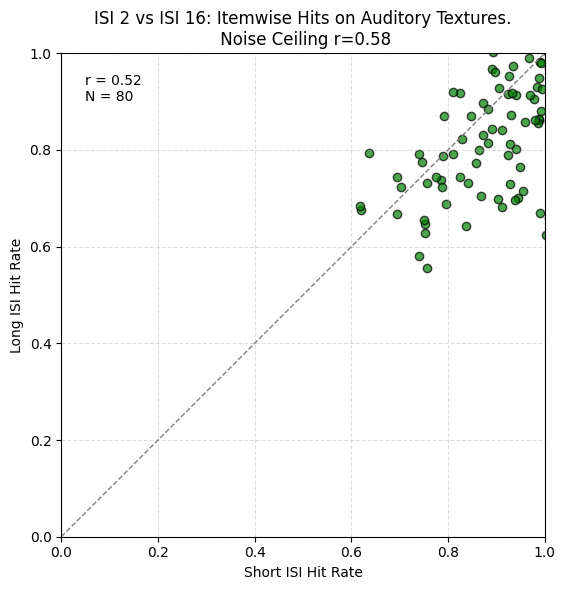

In [40]:
out_hits = plot_cross_experiment_itemwise_relationship(
    results_short,
    results_long,
    kind="hits",
    title=f"ISI {which_isi_short} vs ISI {which_isi_long}: Itemwise Hits on {hr_task_name[which_task]}.\n Noise Ceiling r={noise_ceiling_hits:.2f}",
    jitter=0.01,
    color="green"
)

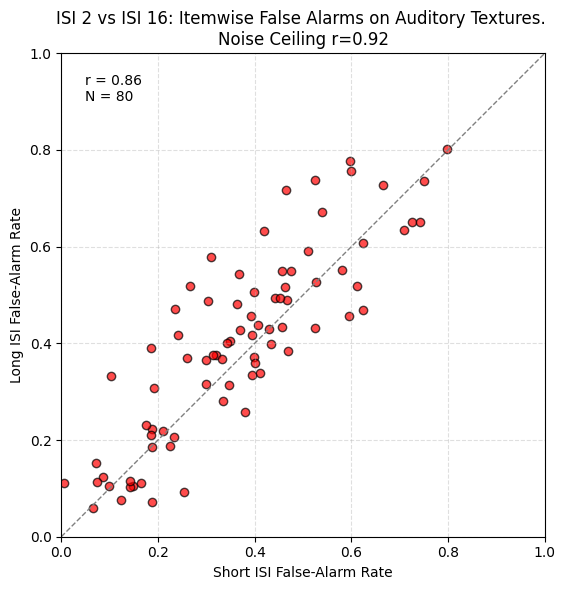

In [41]:
out_fa = plot_cross_experiment_itemwise_relationship(
    results_short,
    results_long,
    kind="false_alarms",
    title=f"ISI {which_isi_short} vs ISI {which_isi_long}: Itemwise False Alarms on {hr_task_name[which_task]}. \nNoise Ceiling r={noise_ceiling_fa:.2f}",
    jitter=0.01,
    color="red"
)

In [25]:
# ===================== Core Rate Extraction =====================
def compute_itemwise_rates_from_subset(results, kind, participant_idx):
    """Compute itemwise hit or FA rates using only selected participants."""
    mat = results["itemwise_responses"][kind]  # DataFrame: participants × items
    subset = mat.iloc[participant_idx]
    return subset.mean(axis=0)  # itemwise average


# ===================== Correlation for downsampled subsets =====================
def compute_downsampled_itemwise_correlation(
    results_short,
    results_long,
    kind,
    n_short,
    n_long,
    seed=None,
):
    """Downsample participants in both experiments, compute itemwise correlation."""
    rng = np.random.default_rng(seed)

    hits_short = results_short["itemwise_responses"][kind]
    hits_long  = results_long["itemwise_responses"][kind]

    # Sample participant indices
    idx_s = rng.choice(hits_short.shape[0], size=n_short, replace=False)
    idx_l = rng.choice(hits_long.shape[0],  size=n_long,  replace=False)

    # Compute itemwise rates
    r_short = compute_itemwise_rates_from_subset(results_short, kind, idx_s)
    r_long  = compute_itemwise_rates_from_subset(results_long,  kind, idx_l)

    # Align items
    common_items = sorted(set(r_short.index) & set(r_long.index))
    r_short = r_short.loc[common_items]
    r_long  = r_long.loc[common_items]

    # Correlation
    return np.corrcoef(r_short, r_long)[0, 1]


# ===================== Power Analysis =====================
def power_analysis_itemwise_correlation(
    results_short,
    results_long,
    kind="hits",
    n_boot=200,
    show_plot=True
):
    """
    For participant counts from 5 to full N, compute distribution of itemwise
    correlations between short and long experiments.
    """
    N_short = results_short["itemwise_responses"][kind].shape[0]
    N_long  = results_long["itemwise_responses"][kind].shape[0]
    N_max   = min(N_short, N_long)

    Ns = np.arange(5, N_max + 1, 5)
    mean_corr = []
    ci_low = []
    ci_high = []

    for n in Ns:
        boot_corrs = []
        for b in range(n_boot):
            r = compute_downsampled_itemwise_correlation(
                results_short,
                results_long,
                kind=kind,
                n_short=n,
                n_long=n,
                seed=None
            )
            boot_corrs.append(r)

        boot_corrs = np.array(boot_corrs)
        mean_corr.append(np.nanmean(boot_corrs))
        ci_low.append(np.nanpercentile(boot_corrs, 2.5))
        ci_high.append(np.nanpercentile(boot_corrs, 97.5))

    # ---- plot ----
    if show_plot:
        plt.figure(figsize=(7, 5))
        plt.plot(Ns, mean_corr, "o-", linewidth=2)
        plt.fill_between(Ns, ci_low, ci_high, alpha=0.2)
        plt.xlabel("Participants per Experiment")
        plt.ylabel(f"Correlation of Itemwise {kind}")
        plt.title(f"Power Curve: Short vs Long ISI ({kind}) on {hr_task_name[which_task]}")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

    return {
        "Ns": Ns,
        "mean": np.array(mean_corr),
        "ci": np.vstack([ci_low, ci_high]).T
    }

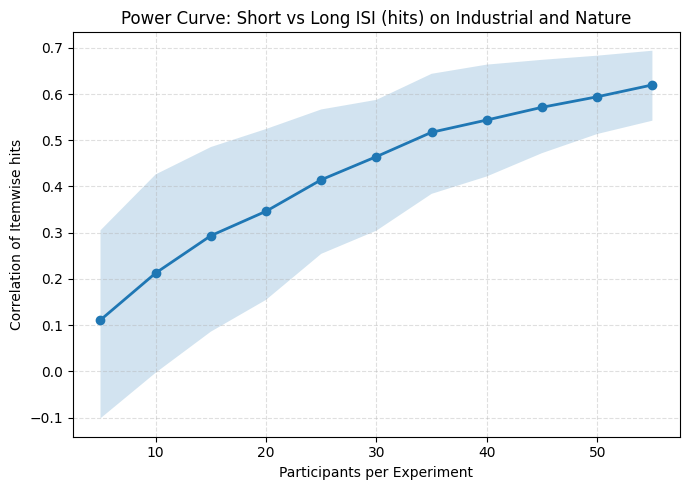

In [26]:
out_hits_power = power_analysis_itemwise_correlation(
    results_short,
    results_long,
    kind="hits",
    n_boot=300
)

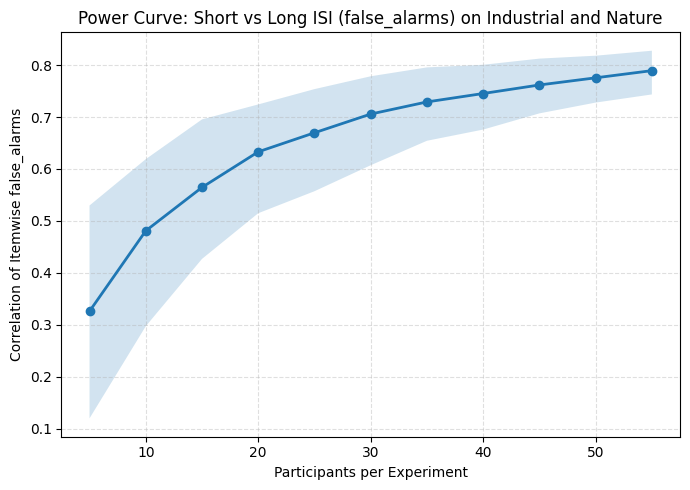

In [27]:
out_fa_power = power_analysis_itemwise_correlation(
    results_short,
    results_long,
    kind="false_alarms",
    n_boot=300
)

In [ ]:
### far_pa_plot_dir = os.path.join(save_dir, f"false-alarm-rate-power-analysis_isi{which_isi}.png")
plot_power_curve(sizes, means, stds, kind="false_alarms", title=f"{hr_task_name[which_task]}: Power Curve for ISI={which_isi} (False Alarms)", save_path=far_pa_plot_dir)